In [1]:
import numpy as np
from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error


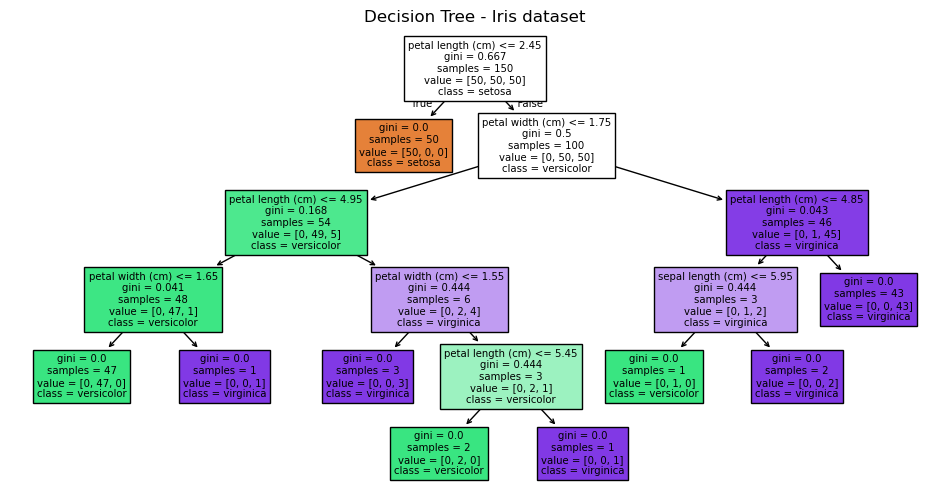

In [8]:

import matplotlib.pyplot as plt

iris = load_iris()
X_iris, y_iris = iris.data, iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# train a classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_iris, y_iris)

# Visualize the tree
plt.figure(figsize=(12, 6))
plot_tree(clf, feature_names=feature_names, class_names=class_names, filled=True)
plt.title("Decision Tree - Iris dataset")
plt.show()


In [3]:


X_h, y_h = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X_h, y_h, test_size=0.25, random_state=42)

depths = list(range(1, 21))
train_rmse = []
test_rmse = []

for d in depths:
    reg = DecisionTreeRegressor(max_depth=d, random_state=42)
    reg.fit(X_train, y_train)
    y_pred_train = reg.predict(X_train)
    y_pred_test = reg.predict(X_test)
    train_rmse.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))


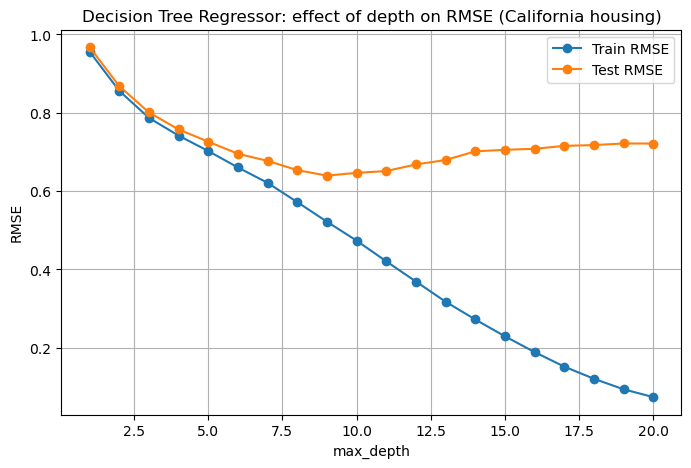

In [4]:

# Plot RMSE vs tree depth
plt.figure(figsize=(8, 5))
plt.plot(depths, train_rmse, label="Train RMSE", marker='o')
plt.plot(depths, test_rmse, label="Test RMSE", marker='o')
plt.xlabel("max_depth")
plt.ylabel("RMSE")
plt.title("Decision Tree Regressor: effect of depth on RMSE (California housing)")
plt.legend()
plt.grid(True)
plt.show()


In [5]:

best_idx = int(np.argmin(test_rmse))
print(f"Best max_depth by test RMSE: {depths[best_idx]} (test RMSE = {test_rmse[best_idx]:.4f}, train RMSE = {train_rmse[best_idx]:.4f})")


Best max_depth by test RMSE: 9 (test RMSE = 0.6391, train RMSE = 0.5215)


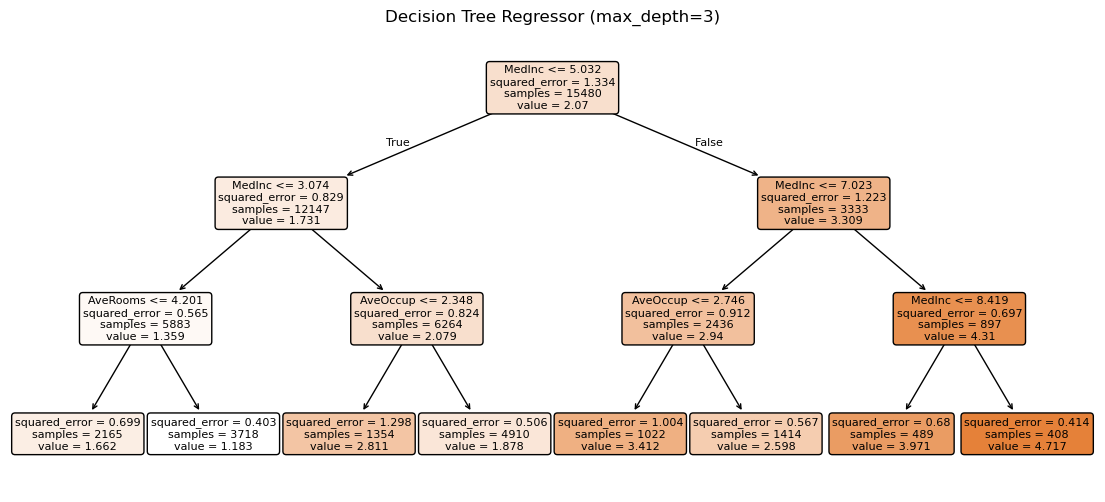

In [7]:

viz_depth = min(depths[best_idx], 3) 
reg_vis = DecisionTreeRegressor(max_depth=viz_depth, random_state=42)
reg_vis.fit(X_train, y_train)

plt.figure(figsize=(14, 6))
plot_tree(reg_vis, feature_names=fetch_california_housing().feature_names, filled=True, rounded=True, fontsize=8)
plt.title(f"Decision Tree Regressor (max_depth={viz_depth})")
plt.show()
